<a href="https://colab.research.google.com/github/jessicasalazar/vision_computador/blob/main/Taller_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop 5
# Airplanes detection
* Download the dataset and image labels
* Create the label matrix ( )
* Model: Feature extractor (Convolutions) + Head (4-variable regression)
* Train with the MSE (Mean Squared Error) loss function

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

torch.manual_seed(42)
np.random.seed(42)

## 1. Cargar y Explorar los Datos

In [ ]:
# Cargar el archivo CSV con las etiquetas
df = pd.read_csv('Airplanes.csv')
print(df.head(10))

In [ ]:
# Verificar el tamaño de una imagen de ejemplo
img_path = 'airplanes_data/image_0001.jpg'
img = Image.open(img_path)
img_width, img_height = img.size

# Visualizar imagen de ejemplo
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

## 2. Crear Matriz de Etiquetas Normalizadas

Las coordenadas se normalizarán dividiendo por el **ancho y alto específico de cada imagen**. Esto es crucial porque las imágenes pueden tener diferentes dimensiones. La normalización permite que el modelo prediga valores entre 0 y 1 para cada coordenada, independientemente del tamaño original de la imagen.

In [ ]:
print("Obteniendo dimensiones de las imágenes...")
image_sizes = []

for img_name in df['Image']:
    img_path_check = f'airplanes_data/{img_name}'
    img_check = Image.open(img_path_check)
    image_sizes.append((img_check.size[0], img_check.size[1]))

df['img_width'] = [size[0] for size in image_sizes]
df['img_height'] = [size[1] for size in image_sizes]
print(f"Total de imágenes: {len(df)}")

In [ ]:
def normalize_bbox_coordinates(df):
    x_top_norm = df['x_top'].values / df['img_width'].values
    y_top_norm = df['y_top'].values / df['img_height'].values
    x_bottom_norm = df['x_bottom'].values / df['img_width'].values
    y_bottom_norm = df['y_bottom'].values / df['img_height'].values

    labels = np.stack([x_top_norm, y_top_norm, x_bottom_norm, y_bottom_norm], axis=1)
    return labels.astype(np.float32)

y_labels = normalize_bbox_coordinates(df)
print(f"Etiquetas normalizadas: {y_labels.shape}")

## 3. Función para Graficar Bounding Boxes en Imágenes

In [ ]:
def plot_image_with_bbox(image_path, bbox_norm, title="Imagen con Bounding Box"):
    img = Image.open(image_path)
    img_width, img_height = img.size

    # Desnormalizar coordenadas
    x_top = bbox_norm[0] * img_width
    y_top = bbox_norm[1] * img_height
    x_bottom = bbox_norm[2] * img_width
    y_bottom = bbox_norm[3] * img_height

    width = x_bottom - x_top
    height = y_bottom - y_top

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img)

    rect = patches.Rectangle((x_top, y_top), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Visualizar ejemplos
for idx in [0, 50, 100]:
    img_name = df.iloc[idx]['Image']
    img_path = f'airplanes_data/{img_name}'
    plot_image_with_bbox(img_path, y_labels[idx], title=f"{img_name}")

## 4. Preparar Dataset para Entrenamiento

Cargar las imágenes y dividir en conjunto de entrenamiento y validación.

In [ ]:
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img_array = np.array(img) / 255.0
    return img_array.astype(np.float32)

def load_dataset(df, data_dir='airplanes_data', target_size=(224, 224)):
    images = []
    for img_name in df['Image']:
        img_path = f"{data_dir}/{img_name}"
        img = load_and_preprocess_image(img_path, target_size)
        images.append(img)
    return np.array(images)

print("Cargando imágenes...")
X_images = load_dataset(df, target_size=(224, 224))
print(f"Imágenes: {X_images.shape}")
print(f"Etiquetas: {y_labels.shape}")

In [ ]:
# Dividir en conjunto de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X_images, y_labels, test_size=0.2, random_state=42
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Conjunto de validación: {X_val.shape[0]} imágenes")
print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")

## 4.5. Data Augmentation Mejorado

Aplicamos augmentación de datos que preserva las coordenadas del bounding box:

In [ ]:
class AirplaneDataset(Dataset):
    """
    Dataset personalizado de PyTorch para imágenes de aviones con augmentación.
    """
    def __init__(self, images, labels, augment=True):
        self.images = torch.FloatTensor(images)
        self.labels = torch.FloatTensor(labels)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        bbox = self.labels[idx].clone()

        if self.augment:
            img, bbox = self.augment_sample(img, bbox)

        # Cambiar de (H, W, C) a (C, H, W) para PyTorch
        img = img.permute(2, 0, 1)

        return img, bbox

    def augment_sample(self, img, bbox):
        """
        Aplica augmentación a una muestra individual.

        Augmentaciones implementadas:
        1. Flip horizontal (50%)
        2. Ajuste de brillo (50%)
        3. Ajuste de contraste (50%)
        4. Ruido gaussiano (50%)
        5. Escalado/Zoom (50%) - factor 0.8-1.2
        6. Traslación/Shift (50%) - desplazamiento -10% a +10%
        """
        # 1. FLIP HORIZONTAL (50%)
        if np.random.rand() > 0.5:
            img = torch.flip(img, dims=[1])  # flip horizontal
            x_old = bbox.clone()
            bbox[0] = 1.0 - x_old[2]  # nuevo x_top = 1 - x_bottom viejo
            bbox[2] = 1.0 - x_old[0]  # nuevo x_bottom = 1 - x_top viejo

        # 2. BRILLO (50%)
        if np.random.rand() > 0.5:
            factor = np.random.uniform(0.7, 1.3)
            img = torch.clamp(img * factor, 0, 1)

        # 3. CONTRASTE (50%)
        if np.random.rand() > 0.5:
            factor = np.random.uniform(0.7, 1.3)
            mean = img.mean()
            img = torch.clamp((img - mean) * factor + mean, 0, 1)

        # 4. RUIDO GAUSSIANO (50%)
        if np.random.rand() > 0.5:
            noise = torch.randn_like(img) * 0.02
            img = torch.clamp(img + noise, 0, 1)

        # 5. ESCALADO/ZOOM (50%)
        if np.random.rand() > 0.5:
            scale_factor = np.random.uniform(0.8, 1.2)

            # Calcular centro del bbox
            center_x = (bbox[0] + bbox[2]) / 2
            center_y = (bbox[1] + bbox[3]) / 2

            # Calcular ancho y alto actuales
            width = bbox[2] - bbox[0]
            height = bbox[3] - bbox[1]

            # Aplicar escala
            new_width = width * scale_factor
            new_height = height * scale_factor

            # Recalcular coordenadas desde el centro
            bbox[0] = center_x - new_width / 2
            bbox[1] = center_y - new_height / 2
            bbox[2] = center_x + new_width / 2
            bbox[3] = center_y + new_height / 2

        # 6. TRASLACIÓN/SHIFT (50%)
        if np.random.rand() > 0.5:
            shift_x = np.random.uniform(-0.1, 0.1)
            shift_y = np.random.uniform(-0.1, 0.1)

            # Aplicar desplazamiento
            bbox[0] += shift_x
            bbox[1] += shift_y
            bbox[2] += shift_x
            bbox[3] += shift_y

        # Asegurar que el bbox está en rango válido [0, 1]
        bbox = torch.clamp(bbox, 0.0, 1.0)

        # Verificar que x_top < x_bottom y y_top < y_bottom
        if bbox[0] >= bbox[2]:
            bbox[0], bbox[2] = bbox[2].clone(), bbox[0].clone()
        if bbox[1] >= bbox[3]:
            bbox[1], bbox[3] = bbox[3].clone(), bbox[1].clone()

        return img, bbox

# Crear datasets de PyTorch
train_dataset = AirplaneDataset(X_train, y_train, augment=True)
val_dataset = AirplaneDataset(X_val, y_val, augment=False)

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}")

## 5. Construir el Modelo de Detección con PyTorch

El modelo consta de:
1. **Extractor de características (Convoluciones)**: Capas convolucionales para extraer características de las imágenes
2. **Cabeza de regresión**: Capas densas que predicen 4 valores continuos (x_top, y_top, x_bottom, y_bottom)

In [ ]:
class AirplaneLocalizationModel(nn.Module):
    """
    Modelo de localización de objetos con hiperparámetros optimizados en PyTorch.

    Arquitectura:
    - Extractor de características: Capas convolucionales
    - Cabeza de regresión: Capas densas que predicen 4 coordenadas
    """
    def __init__(self, dropout_rate=0.3):
        super(AirplaneLocalizationModel, self).__init__()

        # Bloque Conv 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate * 0.5)
        )

        # Bloque Conv 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate * 0.67)
        )

        # Bloque Conv 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate * 0.83)
        )

        # Bloque Conv 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Cabeza de Regresión
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate * 1.33),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate * 1.33),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate),

            # Salida: 4 valores entre 0 y 1 (coordenadas normalizadas)
            nn.Linear(128, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x

# Crear el modelo
model = AirplaneLocalizationModel(dropout_rate=0.3).to(device)


## 6. Compilar el Modelo con MSE (Mean Squared Error)

Definimos la función de pérdida y el optimizador para regresión.

In [ ]:
# Definir función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)

# MEJORA: Scheduler con Cosine Annealing Warm Restarts (mejor exploración)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,        # Reiniciar cada 10 épocas
    T_mult=2,      # Duplicar el periodo después de cada reinicio
    eta_min=1e-7   # Learning rate mínimo
)

print("Optimizador configurado con CosineAnnealingWarmRestarts")

## 7. Entrenar el Modelo

In [ ]:
# MEJORA: Inicializar GradScaler para Mixed Precision Training
use_amp = torch.cuda.is_available()  # Solo usar AMP si hay GPU
scaler = GradScaler() if use_amp else None
print(f"Mixed Precision Training: {'Activado ✓' if use_amp else 'Desactivado (CPU)'}\n")

# Función de entrenamiento MEJORADA
def train_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    running_mae = 0.0

    pbar = tqdm(loader, desc='Entrenando')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # MEJORA: Mixed Precision Training
        if scaler is not None:
            # Forward pass con autocast (usa FP16 automáticamente)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Backward pass con gradientes escalados
            scaler.scale(loss).backward()

            # MEJORA: Gradient Clipping (evita explosión de gradientes)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
        else:
            # Sin Mixed Precision (CPU)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # MEJORA: Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        # Métricas
        running_loss += loss.item() * images.size(0)
        mae = torch.abs(outputs - labels).mean()
        running_mae += mae.item() * images.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'mae': f'{mae.item():.4f}'})

    epoch_loss = running_loss / len(loader.dataset)
    epoch_mae = running_mae / len(loader.dataset)

    return epoch_loss, epoch_mae

# Función de validación (sin cambios)
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_mae = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validando'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            mae = torch.abs(outputs - labels).mean()
            running_mae += mae.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_mae = running_mae / len(loader.dataset)

    return epoch_loss, epoch_mae

# Entrenar el modelo
num_epochs = 50
best_val_loss = float('inf')
patience = 15
patience_counter = 0

history = {
    'loss': [],
    'mae': [],
    'val_loss': [],
    'val_mae': []
}

print("Iniciando entrenamiento con mejoras:")
print("✓ Gradient Clipping (max_norm=1.0)")
print("✓ Mixed Precision Training (si GPU disponible)")
print("✓ Cosine Annealing Warm Restarts\n")

for epoch in range(num_epochs):
    print(f"\nÉpoca {epoch+1}/{num_epochs}")
    print("-" * 50)

    # Entrenar (con scaler para mixed precision)
    train_loss, train_mae = train_epoch(model, train_loader, criterion, optimizer, device, scaler)

    # Validar
    val_loss, val_mae = validate_epoch(model, val_loader, criterion, device)

    # Guardar historial
    history['loss'].append(train_loss)
    history['mae'].append(train_mae)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    # MEJORA: Actualizar learning rate con Cosine Annealing (cada época)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"\nTrain Loss: {train_loss:.6f} - Train MAE: {train_mae:.6f}")
    print(f"Val Loss: {val_loss:.6f} - Val MAE: {val_mae:.6f}")
    print(f"Learning Rate: {current_lr:.7f}")

    # Early stopping y guardar mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print("✓ Mejor modelo guardado!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping en época {epoch+1}")
            break

# Cargar el mejor modelo
model.load_state_dict(torch.load('best_model.pth'))
print("\n¡Entrenamiento completado!")
print(f"Mejor val_loss: {best_val_loss:.6f}")

Validando: 100%|██████████| 5/5 [00:00<00:00,  7.72it/s]




Train Loss: 0.012708 - Train MAE: 0.085706
Val Loss: 0.002488 - Val MAE: 0.042083
Learning Rate: 0.0004969
✓ Mejor modelo guardado!

Época 33/50
--------------------------------------------------


Validando: 100%|██████████| 5/5 [00:00<00:00,  9.97it/s]




Train Loss: 0.011412 - Train MAE: 0.082055
Val Loss: 0.002122 - Val MAE: 0.035539
Learning Rate: 0.0004931
✓ Mejor modelo guardado!

Época 34/50
--------------------------------------------------


Validando: 100%|██████████| 5/5 [00:00<00:00,  9.92it/s]



...


Train Loss: 0.007400 - Train MAE: 0.062197
Val Loss: 0.001391 - Val MAE: 0.023117
Learning Rate: 0.0002892

Época 49/50
--------------------------------------------------


Validando: 100%|██████████| 5/5 [00:00<00:00,  8.87it/s]



Train Loss: 0.008078 - Train MAE: 0.066818
Val Loss: 0.001718 - Val MAE: 0.025577
Learning Rate: 0.0002697

Época 50/50
--------------------------------------------------


Validando: 100%|██████████| 5/5 [00:00<00:00,  7.32it/s]



Train Loss: 0.007036 - Train MAE: 0.064923
Val Loss: 0.001647 - Val MAE: 0.024931
Learning Rate: 0.0002501

¡Entrenamiento completado!
Mejor val_loss: 0.001258


## 8. Visualizar el Progreso del Entrenamiento

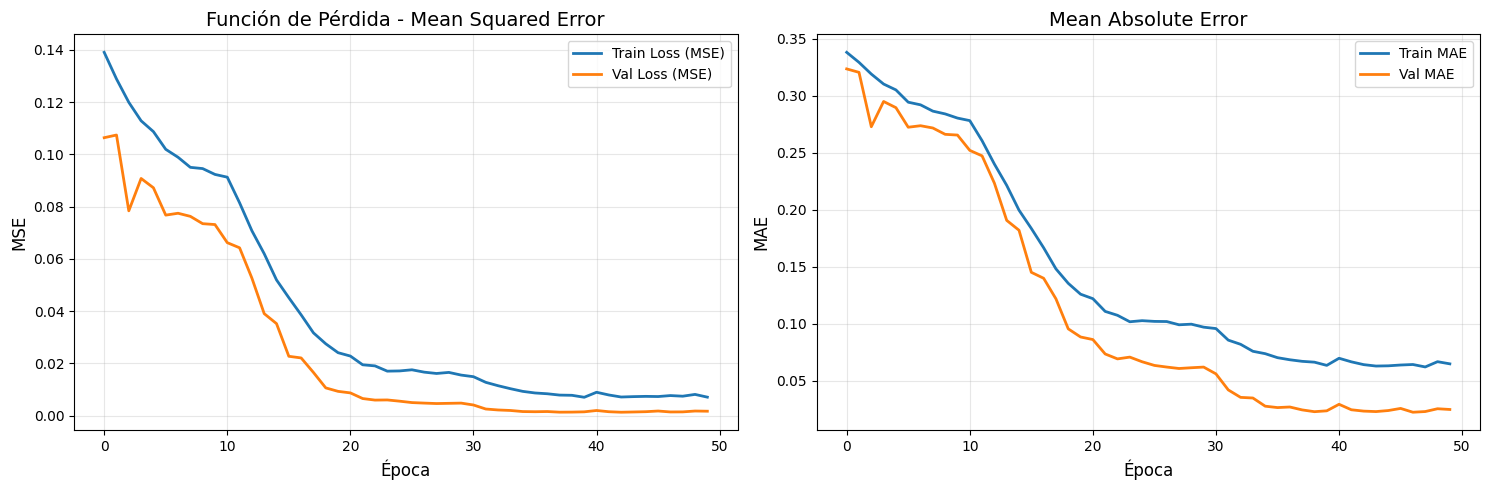


Mejor época: 43
MSE (train): 0.007087
MSE (val): 0.001258


In [ ]:
# Graficar pérdida y métricas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pérdida (MSE)
axes[0].plot(history['loss'], label='Train Loss (MSE)', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss (MSE)', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('Función de Pérdida - Mean Squared Error', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Mean Absolute Error', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar mejor época
best_epoch = np.argmin(history['val_loss'])
print(f"\nMejor época: {best_epoch + 1}")
print(f"MSE (train): {history['loss'][best_epoch]:.6f}")
print(f"MSE (val): {history['val_loss'][best_epoch]:.6f}")

## 9. Evaluar el Modelo y Visualizar Predicciones

In [ ]:
# Hacer predicciones en el conjunto de validación
print("Generando predicciones en el conjunto de validación...")
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Prediciendo'):
        images = images.to(device)
        outputs = model(images)
        all_predictions.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

y_pred = np.vstack(all_predictions)
y_val_np = np.vstack(all_labels)

# Estadísticas generales
errors = np.abs(y_pred - y_val_np)
print(f"\n{'='*70}")
print("📈 ESTADÍSTICAS GENERALES DE ERROR")
print(f"{'='*70}")
print(f"Error absoluto promedio (MAE): {errors.mean():.4f}")
print(f"Error absoluto mediano: {np.median(errors):.4f}")
print(f"Error mínimo: {errors.min():.4f}")
print(f"Error máximo: {errors.max():.4f}")
print(f"Desviación estándar: {errors.std():.4f}")
print(f"{'='*70}\n")

Generando predicciones en el conjunto de validación...


Prediciendo: 100%|██████████| 5/5 [00:00<00:00,  7.39it/s]


📈 ESTADÍSTICAS GENERALES DE ERROR
Error absoluto promedio (MAE): 0.0235
Error absoluto mediano: 0.0164
Error mínimo: 0.0001
Error máximo: 0.2162
Desviación estándar: 0.0266



Visualizando predicciones en el conjunto de validación...



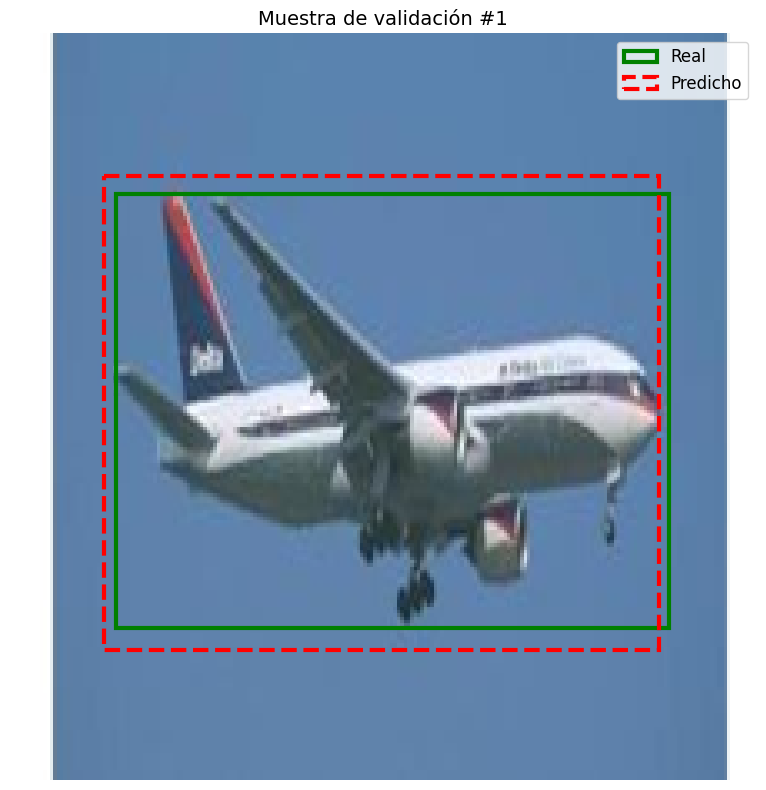

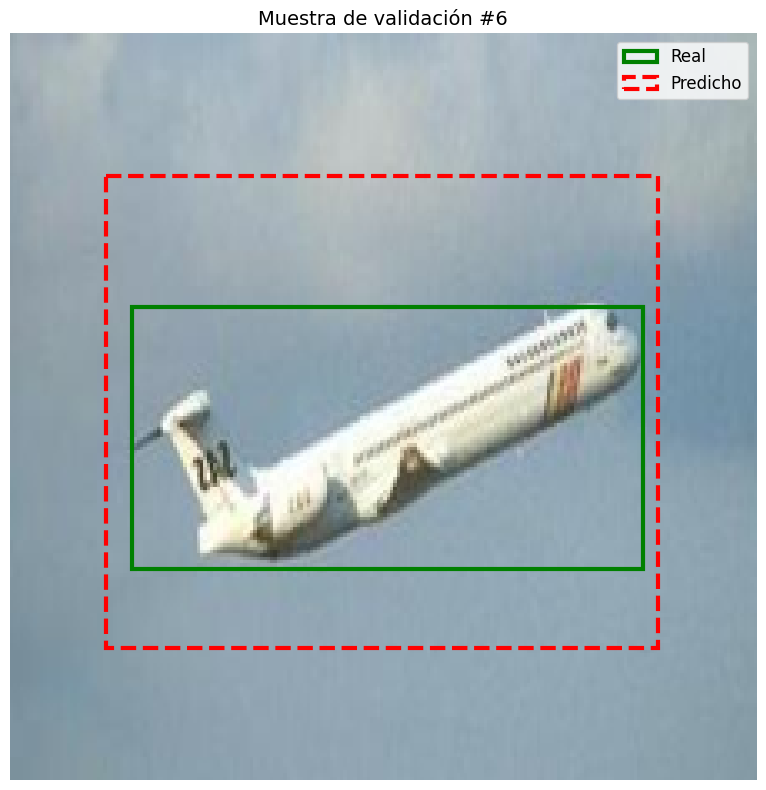

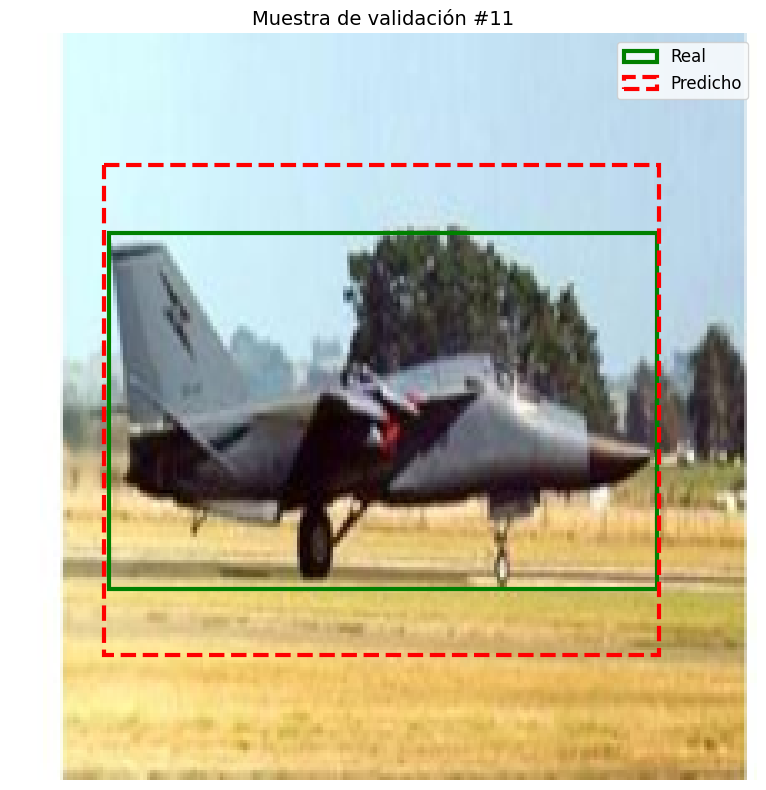

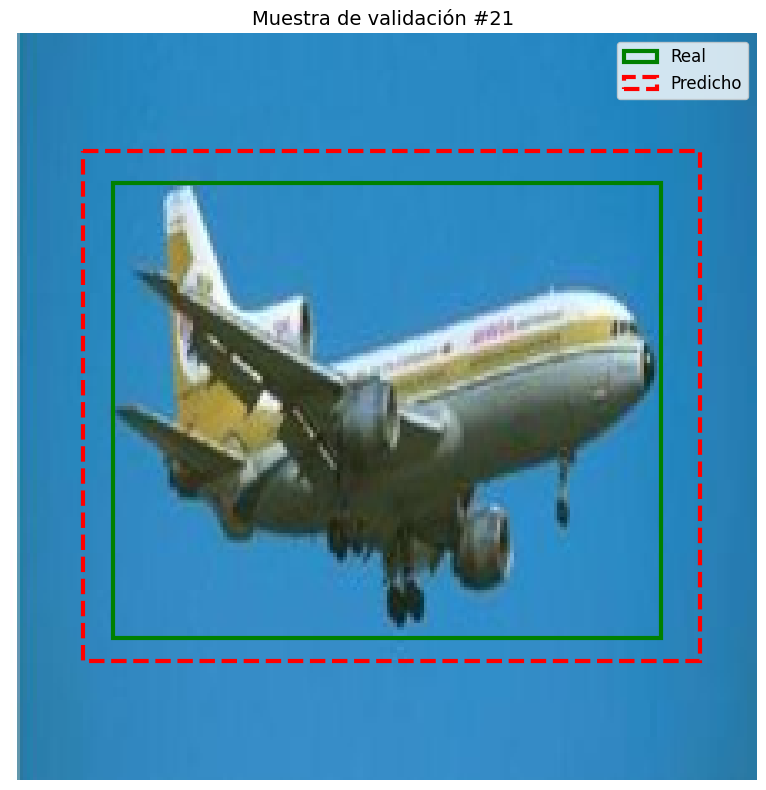

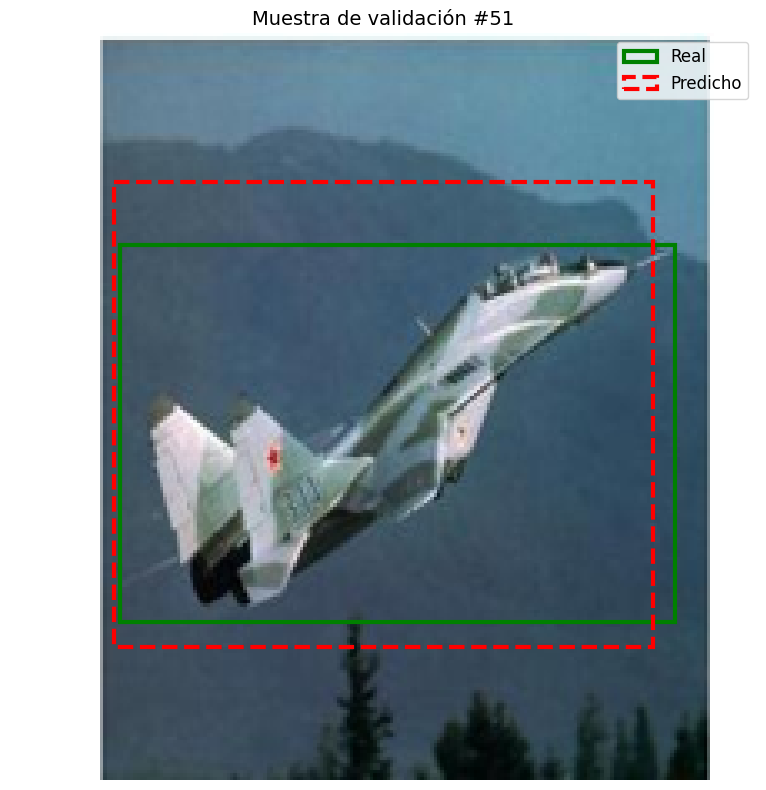

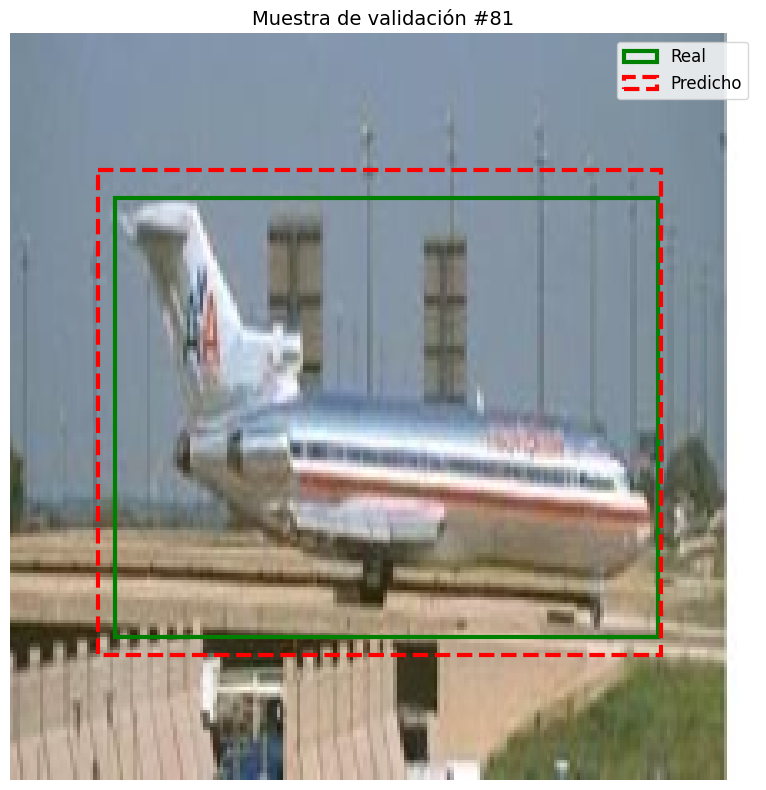

In [ ]:
def plot_prediction_comparison(image, bbox_true, bbox_pred, title="Comparación"):
    fig, ax = plt.subplots(1, figsize=(10, 8))

    # Convertir imagen si es tensor de PyTorch
    if isinstance(image, torch.Tensor):
        # De (C, H, W) a (H, W, C)
        image = image.permute(1, 2, 0).cpu().numpy()

    # Mostrar imagen
    ax.imshow(image)

    # Calcular coordenadas en píxeles (imagen de 224x224)
    img_size = 224

    # Bounding box real (verde)
    x_top_true = bbox_true[0] * img_size
    y_top_true = bbox_true[1] * img_size
    x_bottom_true = bbox_true[2] * img_size
    y_bottom_true = bbox_true[3] * img_size
    width_true = x_bottom_true - x_top_true
    height_true = y_bottom_true - y_top_true

    rect_true = patches.Rectangle((x_top_true, y_top_true), width_true, height_true,
                                  linewidth=3, edgecolor='green', facecolor='none',
                                  label='Real')
    ax.add_patch(rect_true)

    # Bounding box predicho (rojo)
    x_top_pred = bbox_pred[0] * img_size
    y_top_pred = bbox_pred[1] * img_size
    x_bottom_pred = bbox_pred[2] * img_size
    y_bottom_pred = bbox_pred[3] * img_size
    width_pred = x_bottom_pred - x_top_pred
    height_pred = y_bottom_pred - y_top_pred

    rect_pred = patches.Rectangle((x_top_pred, y_top_pred), width_pred, height_pred,
                                 linewidth=3, edgecolor='red', facecolor='none',
                                 linestyle='--', label='Predicho')
    ax.add_patch(rect_pred)

    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Visualizar algunas predicciones
print("Visualizando predicciones en el conjunto de validación...\n")
indices = [0, 5, 10, 20, 50, 80]

for idx in indices:
    # Obtener imagen del dataset (sin augmentación)
    img_tensor, _ = val_dataset[idx]

    plot_prediction_comparison(
        img_tensor,
        y_val_np[idx],
        y_pred[idx],
        title=f"Muestra de validación #{idx+1}"
    )

## 10. Métricas de Evaluación (IoU - Intersection over Union)

Métricas de Evaluación (IoU):
IoU promedio: 0.8706
IoU mediano: 0.9032
IoU mínimo: 0.4866
IoU máximo: 0.9861
Desviación estándar: 0.0946


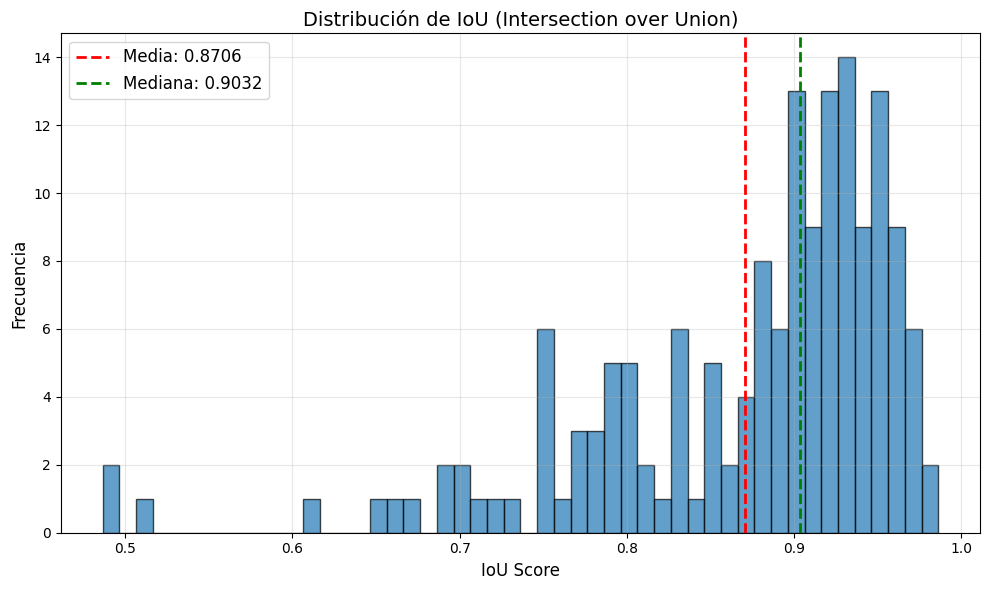

In [ ]:
def calculate_iou(bbox_true, bbox_pred):

    # Coordenadas de la intersección
    x_left = max(bbox_true[0], bbox_pred[0])
    y_top = max(bbox_true[1], bbox_pred[1])
    x_right = min(bbox_true[2], bbox_pred[2])
    y_bottom = min(bbox_true[3], bbox_pred[3])

    # Área de intersección
    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # Áreas de los bounding boxes
    bbox_true_area = (bbox_true[2] - bbox_true[0]) * (bbox_true[3] - bbox_true[1])
    bbox_pred_area = (bbox_pred[2] - bbox_pred[0]) * (bbox_pred[3] - bbox_pred[1])

    # Área de unión
    union_area = bbox_true_area + bbox_pred_area - intersection_area

    # IoU
    iou = intersection_area / union_area if union_area > 0 else 0.0

    return iou

# Calcular IoU para todas las predicciones
ious = []
for i in range(len(y_val)):
    iou = calculate_iou(y_val[i], y_pred[i])
    ious.append(iou)

ious = np.array(ious)

print("Métricas de Evaluación (IoU):")
print(f"IoU promedio: {ious.mean():.4f}")
print(f"IoU mediano: {np.median(ious):.4f}")
print(f"IoU mínimo: {ious.min():.4f}")
print(f"IoU máximo: {ious.max():.4f}")
print(f"Desviación estándar: {ious.std():.4f}")

# Distribución de IoU
plt.figure(figsize=(10, 6))
plt.hist(ious, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(ious.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {ious.mean():.4f}')
plt.axvline(np.median(ious), color='green', linestyle='--', linewidth=2, label=f'Mediana: {np.median(ious):.4f}')
plt.xlabel('IoU Score', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de IoU (Intersection over Union)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()